In [1]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()

# Lecture 4 (Makemore pt 3): Notes on MLP internals: Activations, Gradients, BatchNorm

In [29]:
# change log

# fix softmax was confidently wrong by initializing to more uniform (maximal entropy) distribution (want values near zero)
        # can know our expected initial loss with -log(1/27) because 27 character alphabet

# fix tanh layer too saturdated at initialization
        # want h to be near zero so that tanh doesnt saturate too much
        # if most tanh(hpreact) ~ -1 or 1, then grad of tanh ~ 0, --> dead neuron

# as you multiply guassians together, the standard deviations increase (guassian noise propogates). thus you need to scale it by gain / sqrt(sample size)
# common way to initialize a neural net for this is: torch.nn.init.kaiming_normal_
# often just scale by 1 / sqrt(fan_in), fan_in = number of layer inputs

# batch normalization 
# Paper: Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift 
# https://arxiv.org/pdf/1502.03167
        # for reasons discussed above, we want the hidden layer (pre-activation) to be roughly guassian with mean 0 and sd 1 at initialization
        # thus we simply normalize the layer (on the training batch) so that it is
        # this is okay because normalization is a differential operation so its fine for back-prop
        # note that we want the layer to be roughly guassian at initialization, but not forced to be at all steps
        # thus implement scale and shift
        # ...what if the same issue with grad = 0 occurs later in the loop...?
        # important note about consequence at around 51-52 min of vid 4:
                # examples in the batch are mathematically coupled in the forward pass because (?) hidden layer is now a function of the batch statistics (thus of other randomly selected examples)
        # but this acts as a regularizer too
        # other normalization methods that do not have this effect: layer normalization, instance normalization, group normalization             

In [30]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)


In [31]:
# Built dataset
block_size = 3

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] 
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) # training set 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # dev set 10%
Xte, Yte = build_dataset(words[n2:]) # test set 10%


In [32]:
# Construct and Initialize MLP
n_embd = 10 # the dimensionality of the character embedding vectors (latent space dimension I believe)
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),               generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden),   generator=g) * (5/3) / ((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                          generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),            generator=g) * 0.01
b2 = torch.randn(vocab_size,                        generator=g) * 0

# scale and shift for batch normalization output
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # total number of parameters in model
for p in parameters:
    p.requires_grad = True

12297


In [37]:
# Gradient Descent
max_steps = 200000
batch_size = 32
lossi = []


for i in range(max_steps):
    
    # minibatch construction (for computational speed)
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g) # samples 32 indexes from dataset
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y
    
    # forward pass
    emb = C[Xb] # embed the chars into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias # batch normalization
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer (log counts)
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update parameters
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    # track states
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d} : {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000 : 2.3386
  10000/ 200000 : 2.2909
  20000/ 200000 : 2.3236
  30000/ 200000 : 2.1656
  40000/ 200000 : 2.2064
  50000/ 200000 : 2.2547
  60000/ 200000 : 1.7855
  70000/ 200000 : 2.5458
  80000/ 200000 : 2.0694
  90000/ 200000 : 2.4889
 100000/ 200000 : 2.3491
 110000/ 200000 : 2.2688
 120000/ 200000 : 1.8060
 130000/ 200000 : 2.1982
 140000/ 200000 : 2.0594
 150000/ 200000 : 1.7811
 160000/ 200000 : 2.2588
 170000/ 200000 : 2.0776
 180000/ 200000 : 2.2990
 190000/ 200000 : 2.1843


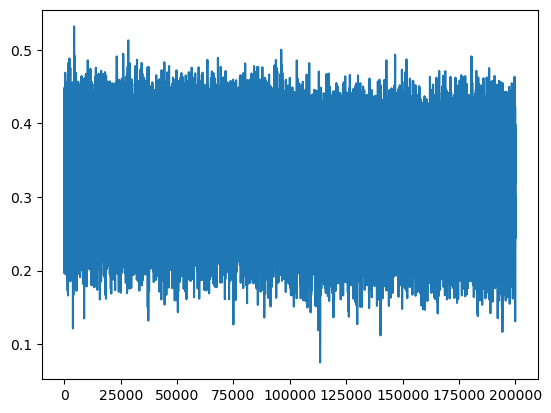

In [38]:
plt.plot(lossi)

In [39]:
@torch.no_grad() # this decorator disables gradient tracking (just for efficiency)
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev), # validation (development)
        'test': (Xte, Yte)
    }[split]
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias # batch normalization
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())
    
split_loss('train')
split_loss('val')

train 2.049262523651123
val 2.1034598350524902


In [49]:
# Sample from the Model

g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with ...
    while True:
        emb = C[torch.tensor([context])] # embed the current context
        h = torch.tanh(emb.view(1,-1) @ W1 + b1) # project embedding into the hidden layer (latent space)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1) # get prob distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item() # sample index of next char from prob distribution
        context = context[1:] + [ix] # shift context window
        if ix == 0:
            break
        out.append(ix)
        

    print(''.join(itos[i] for i in out))

carlahlaylihlailkimrixatthl
stafsslejsabubrddgerricharquianafturfariziivdysleilyhhll
fsantensluzsslivennyferquiqzellgithrishkarlengirratzelyzaiiahktleyarshly
luqshivdricsyahntzalsoz
zjunessiadaslacelkp
sadunjudnorgerkorachrinhlaqsachanrykeldenxloznpryceldayaf
quintygbfcorrixanncesslyvikrntydnnyshnttre
khnasuftte
strtejland
quiahsorgkorryiahnnykirrew
zairdza
marlellanniqurrschprytzy
bakyigluducklrrysssofyamishkanshaddlyh
torallardelisawrdnv
quiaz
stza
rvelkhlayatissaddgygmussulgervdhxadafssdaffriqwidtt
straydanshjqawgarriestlquardlekstavhuntleydanaehlanlyn
jussimbiyvhnstya
zacirrentarlynneslaylianniketlsnadisarrightaj
